In [3]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
import pywt
import warnings
warnings.filterwarnings('ignore')

with rasterio.open('../data/raw/S2_Season1_BOA_Composite.tif') as src:
    data = src.read().astype(np.float32)

data = np.nan_to_num(data, nan=0.0)
B4, B8 = data[2], data[6]
ndvi = np.where((B8+B4)!=0, (B8-B4)/(B8+B4), 0)
ndvi_norm = np.clip((ndvi+1)/2, 0, 1)

h, w = ndvi_norm.shape
scale = 3
ndvi_lr = resize(ndvi_norm, (h//scale, w//scale), anti_aliasing=True)
ndvi_bicubic = resize(ndvi_lr, (h, w), order=3, anti_aliasing=True)

print(f"HR shape: {ndvi_norm.shape}")
print(f"LR shape: {ndvi_lr.shape}")
print(f"Bicubic PSNR: {psnr(ndvi_norm, ndvi_bicubic, data_range=1.0):.2f} dB")

HR shape: (1146, 1001)
LR shape: (382, 333)
Bicubic PSNR: 30.91 dB


In [4]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 1,  5, padding=2)
        self.relu  = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.conv3(self.relu(self.conv2(self.relu(self.conv1(x)))))

# Extract patches
ps, stride, max_p = 32, 32, 500
hr_p, lr_p = [], []
for i in range(0, h-ps, stride):
    for j in range(0, w-ps, stride):
        hr_p.append(ndvi_norm[i:i+ps, j:j+ps])
        lr_p.append(ndvi_bicubic[i:i+ps, j:j+ps])
        if len(hr_p) >= max_p: break
    if len(hr_p) >= max_p: break

hr_t = torch.FloatTensor(np.array(hr_p)).unsqueeze(1)
lr_t = torch.FloatTensor(np.array(lr_p)).unsqueeze(1)
loader = DataLoader(TensorDataset(lr_t, hr_t), batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SRCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses = []
for epoch in range(20):
    loss_sum = 0
    for lr_b, hr_b in loader:
        lr_b, hr_b = lr_b.to(device), hr_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(lr_b), hr_b)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    losses.append(loss_sum/len(loader))
    if (epoch+1)%5==0: print(f"Epoch {epoch+1}/20 Loss: {losses[-1]:.6f}")

print("Training complete")

Epoch 5/20 Loss: 0.002840
Epoch 10/20 Loss: 0.001525
Epoch 15/20 Loss: 0.001060
Epoch 20/20 Loss: 0.000915
Training complete


In [5]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 1,  5, padding=2)
        self.relu  = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.conv3(self.relu(self.conv2(self.relu(self.conv1(x)))))

# Extract patches
ps, stride, max_p = 32, 32, 500
hr_p, lr_p = [], []
for i in range(0, h-ps, stride):
    for j in range(0, w-ps, stride):
        hr_p.append(ndvi_norm[i:i+ps, j:j+ps])
        lr_p.append(ndvi_bicubic[i:i+ps, j:j+ps])
        if len(hr_p) >= max_p: break
    if len(hr_p) >= max_p: break

hr_t = torch.FloatTensor(np.array(hr_p)).unsqueeze(1)
lr_t = torch.FloatTensor(np.array(lr_p)).unsqueeze(1)
loader = DataLoader(TensorDataset(lr_t, hr_t), batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SRCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses = []
for epoch in range(20):
    loss_sum = 0
    for lr_b, hr_b in loader:
        lr_b, hr_b = lr_b.to(device), hr_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(lr_b), hr_b)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    losses.append(loss_sum/len(loader))
    if (epoch+1)%5==0: print(f"Epoch {epoch+1}/20 Loss: {losses[-1]:.6f}")

print("Training complete")

Epoch 5/20 Loss: 0.003014
Epoch 10/20 Loss: 0.001859
Epoch 15/20 Loss: 0.001275
Epoch 20/20 Loss: 0.001048
Training complete


Bicubic PSNR: 30.91 dB  SSIM: 0.8326
SRCNN   PSNR: 30.48 dB  SSIM: 0.8198
Wavelet PSNR: 26.14 dB  SSIM: 0.5438


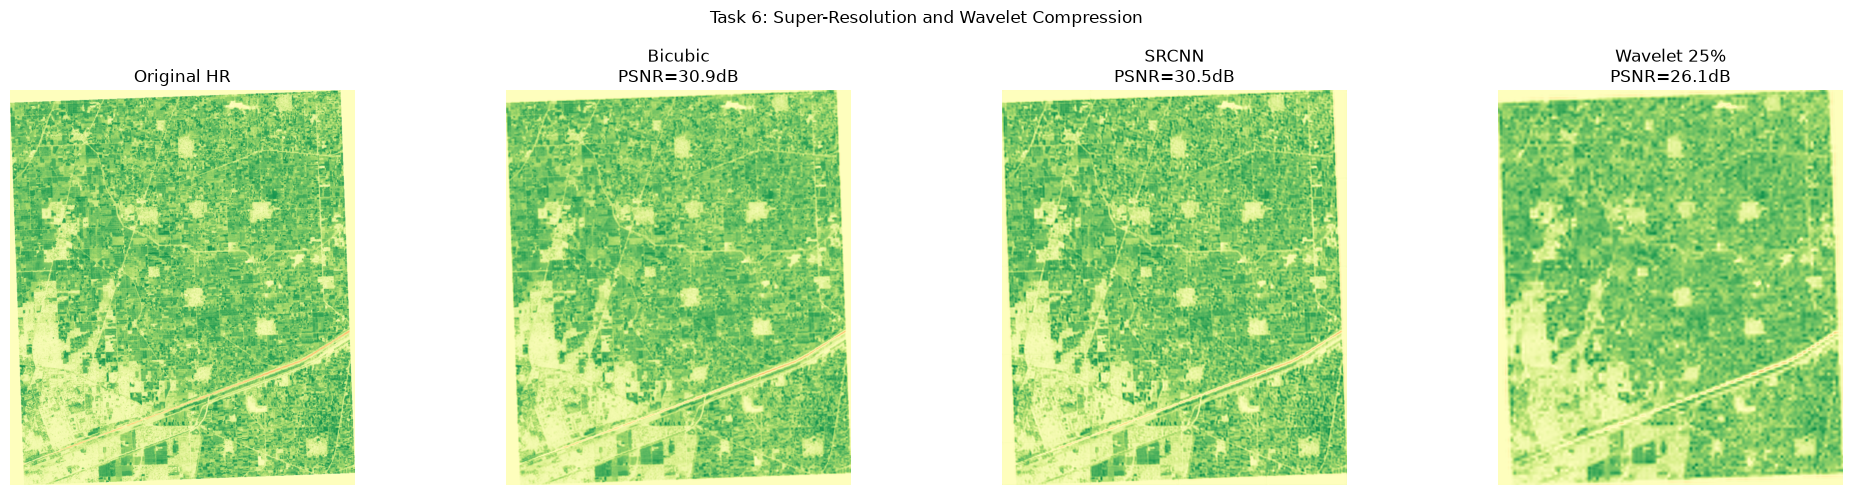

In [6]:
model.eval()
tile = 256
out = np.zeros_like(ndvi_norm)
with torch.no_grad():
    for i in range(0, h, tile):
        for j in range(0, w, tile):
            t = torch.FloatTensor(ndvi_bicubic[i:i+tile, j:j+tile]).unsqueeze(0).unsqueeze(0).to(device)
            p = model(t).squeeze().cpu().numpy()
            out[i:i+p.shape[0], j:j+p.shape[1]] = p

out = np.clip(out, 0, 1)

# Wavelet compression
def wavelet_compress(img, keep=0.1):
    coeffs = pywt.wavedec2(img, 'db4', level=3)
    thr = np.percentile(np.abs(coeffs[0]), (1-keep)*100)
    new_c = [coeffs[0]] + [tuple(np.where(np.abs(d)>thr,d,0) for d in det) for det in coeffs[1:]]
    rec = pywt.waverec2(new_c, 'db4')
    return rec[:h, :w]

comp = wavelet_compress(ndvi_norm, keep=0.25)

print(f"Bicubic PSNR: {psnr(ndvi_norm, ndvi_bicubic, data_range=1.0):.2f} dB  SSIM: {ssim(ndvi_norm, ndvi_bicubic, data_range=1.0):.4f}")
print(f"SRCNN   PSNR: {psnr(ndvi_norm, out,           data_range=1.0):.2f} dB  SSIM: {ssim(ndvi_norm, out,           data_range=1.0):.4f}")
print(f"Wavelet PSNR: {psnr(ndvi_norm, comp,          data_range=1.0):.2f} dB  SSIM: {ssim(ndvi_norm, comp,         data_range=1.0):.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (img, title) in zip(axes, [
    (ndvi_norm,    'Original HR'),
    (ndvi_bicubic, f'Bicubic\nPSNR={psnr(ndvi_norm,ndvi_bicubic,data_range=1.0):.1f}dB'),
    (out,          f'SRCNN\nPSNR={psnr(ndvi_norm,out,data_range=1.0):.1f}dB'),
    (comp,         f'Wavelet 25%\nPSNR={psnr(ndvi_norm,comp,data_range=1.0):.1f}dB'),
]):
    ax.imshow(img, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Task 6: Super-Resolution and Wavelet Compression')
plt.tight_layout()
plt.savefig('../data/outputs/task6_notebook_output.png', dpi=150)
plt.show()